Ali Hisham AlJamed 2240005868

# Digital Image Processing Lab
## 1. Image Sampling and Quantization
## 2. Arithmetic Operations
## 3. Set and Logical Operations

## 1. Image Sampling and Quantization
### Step 1: Import the libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Define Functions

In [2]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.

    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.

    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor),
                                interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.

    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.

    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.

    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()

### Step 3: Import the image and set the parameters

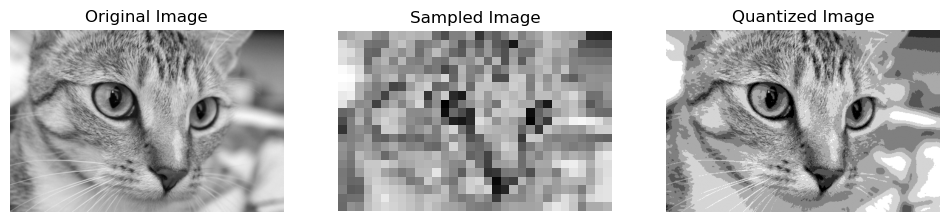

In [4]:
import skimage as ski

sampling_factor = 14
quantization_levels = 9

# Load the 'cat' sample image and convert it to grayscale
original_image = ski.color.rgb2gray(ski.data.cat())
original_image = (original_image * 255).astype(np.uint8)

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

### Task #1: Change the sampling and quantization parameters and observe the effects
Try a few different values of `sampling_factor` (e.g. 2, 4, 8, 16, 32) and `quantization_levels` (e.g. 2, 4, 8, 16, 32, 64) and see how the image quality degrades as sampling factor increases and quantization levels decrease.

In [ ]:
# Try several sampling factors and quantization levels for comparison
test_sampling_factors = [2, 4, 8, 16, 32]
test_quantization_levels = [2, 4, 8, 16, 32]

for factor in test_sampling_factors:
    sampled_test = sample_image(original_image, factor)
    plt.figure(figsize=(3, 3))
    plt.imshow(sampled_test, cmap='gray')
    plt.title(f'Sampling factor = {factor}')
    plt.axis('off')
    plt.show()

for levels in test_quantization_levels:
    quantized_test = quantize_image(original_image, levels)
    plt.figure(figsize=(3, 3))
    plt.imshow(quantized_test, cmap='gray')
    plt.title(f'Quantization levels = {levels}')
    plt.axis('off')
    plt.show()

## 2. Arithmetic Operations

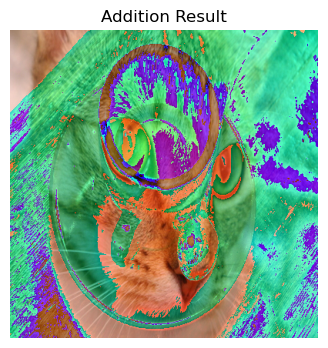

In [5]:
from PIL import Image
import skimage as ski

img1 = Image.fromarray(ski.data.cat())
img2 = Image.fromarray(ski.data.coffee())

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
resultImage = Image.fromarray(addition)
resultImage.show()

# Also display inline in the notebook
plt.figure(figsize=(4, 4))
plt.imshow(resultImage, cmap='gray')
plt.title('Addition Result')
plt.axis('off')
plt.show()

## 3. Sets and Logical Operations

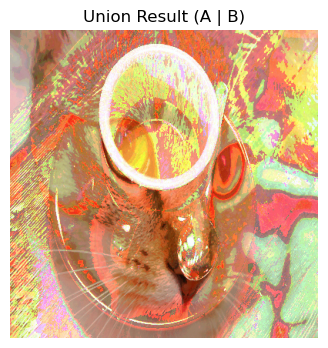

In [6]:
img3 = Image.fromarray(ski.data.cat())
img4 = Image.fromarray(ski.data.coffee())

resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union)
resultImage2.show()

# Also display inline in the notebook
plt.figure(figsize=(4, 4))
plt.imshow(resultImage2, cmap='gray')
plt.title('Union Result (A | B)')
plt.axis('off')
plt.show()

### Task #2: Read two images, convert them into arrays, and perform the following operations
1. Subtract two images and display the result.
2. Add one image with a constant value of 175 and display it.
3. Apply the set difference operation on two grayscale images.
4. Apply the symmetric difference operation on two grayscale images.
5. Apply the intersection operation on two grayscale images.

**Note:** For arithmetic (subtract / add-constant) we use `cv2.subtract` / `cv2.add` instead of plain `-`/`+` on the numpy arrays, because those OpenCV functions *saturate* the result to the valid `[0, 255]` range instead of wrapping around (overflowing), which is what would happen with raw numpy uint8 arithmetic.

For the **set-style** operations (difference, symmetric difference, intersection) we use the bitwise operators (`&`, `|`, `^`, `~`) exactly like the union example above, since a set difference `A - B` on images corresponds to `A AND NOT B`.

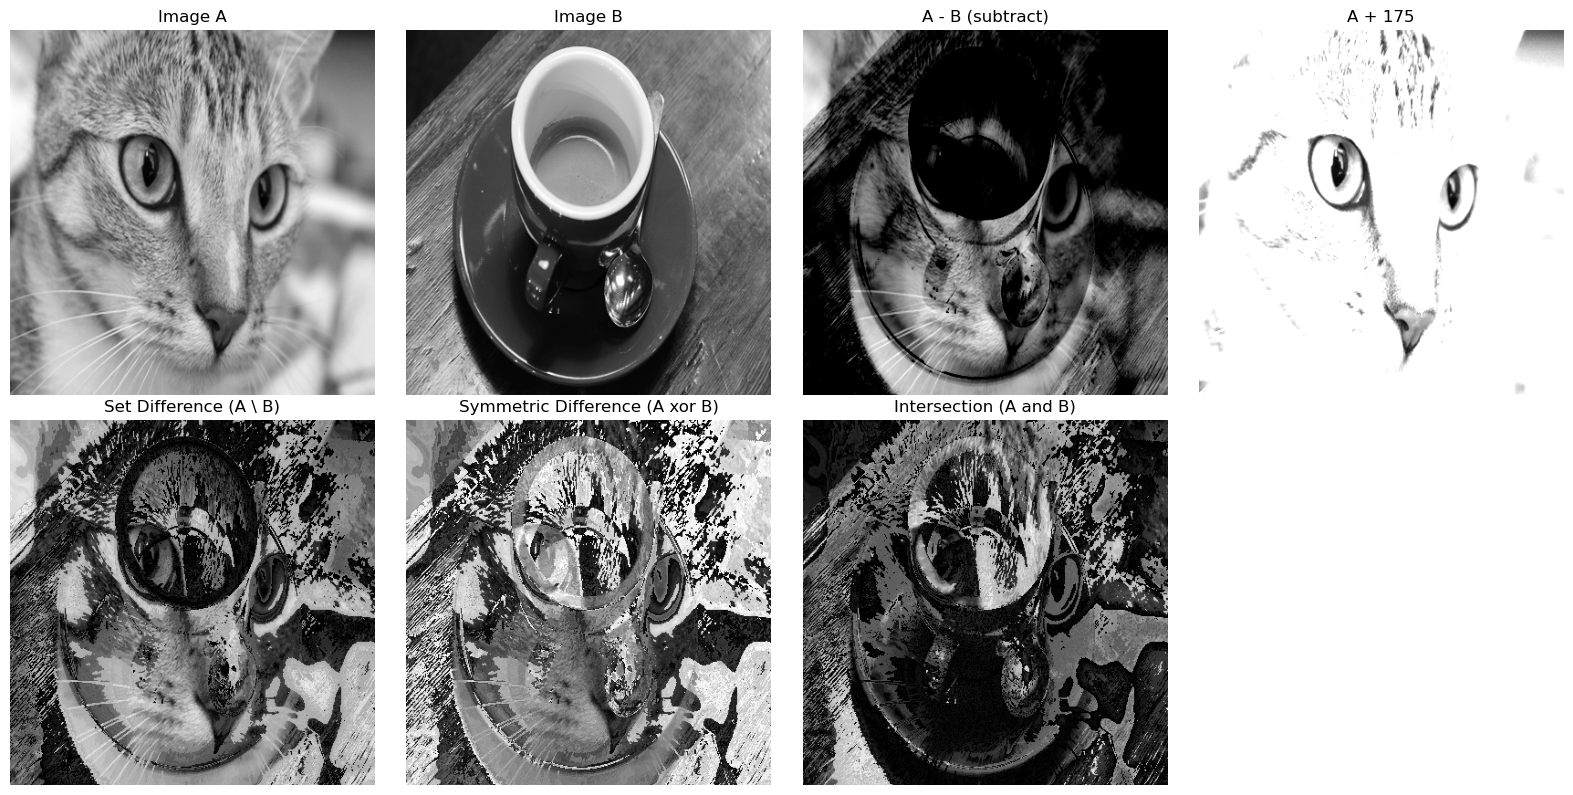

In [8]:
import skimage as ski

# Load the cat and coffee sample images, convert to grayscale
imgA = Image.fromarray((ski.color.rgb2gray(ski.data.cat()) * 255).astype(np.uint8))
imgB = Image.fromarray((ski.color.rgb2gray(ski.data.coffee()) * 255).astype(np.uint8))

resize = (400, 400)
imgA = imgA.resize(resize, Image.Resampling.LANCZOS)
imgB = imgB.resize(resize, Image.Resampling.LANCZOS)

arrA = np.asarray(imgA)
arrB = np.asarray(imgB)

# ---- 1. Subtraction (saturated, no wrap-around) ----
subtraction = cv2.subtract(arrA, arrB)
resultSub = Image.fromarray(subtraction)

# ---- 2. Add a constant value of 175 (saturated) ----
constant = 175
addConstant = cv2.add(arrA, np.full(arrA.shape, constant, dtype=np.uint8))
resultAddConst = Image.fromarray(addConstant)

# ---- 3. Set difference: A - B  =  A AND (NOT B) ----
setDifference = arrA & (~arrB)
resultSetDiff = Image.fromarray(setDifference)

# ---- 4. Symmetric difference: A XOR B ----
symmetricDifference = arrA ^ arrB
resultSymDiff = Image.fromarray(symmetricDifference)

# ---- 5. Intersection: A AND B ----
intersection = arrA & arrB
resultIntersection = Image.fromarray(intersection)

# Plot everything together
titles = ['Image A', 'Image B', 'A - B (subtract)', 'A + 175',
          'Set Difference (A \ B)', 'Symmetric Difference (A xor B)',
          'Intersection (A and B)']
images = [arrA, arrB, subtraction, addConstant,
          setDifference, symmetricDifference, intersection]

plt.figure(figsize=(16, 8))
for i, (title, im) in enumerate(zip(titles, images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(im, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()